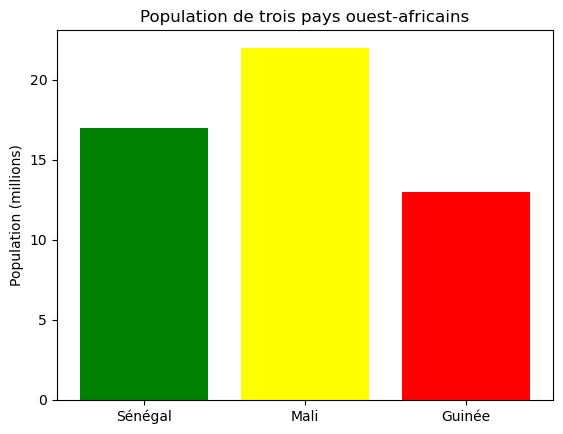

In [4]:
import matplotlib.pyplot as plt

# Données
pays = ['Sénégal', 'Mali', 'Guinée']
population = [17, 22, 13]  # en millions

# Question 1 : Que fait cette ligne ?
fig, ax = plt.subplots()
# Réponse : cette ligne affichera ou désignera l'espace de dessin/graphisme, où fig est une figure et axe un ensemble de sous-grapheques

# Question 2 : Que va afficher cette ligne ?
ax.bar(pays, population, color=['green', 'yellow', 'red'])
# Réponse : cette ligne affrichera le diagramme en bar avec les couleurs verte,jaune et rouge, et avec sur l'axe de X les pays de l'ouest-africains de en sur l'axe de y les differentes populations

# Question 3 : Quel est le rôle de ax.set_ylabel ?
ax.set_ylabel('Population (millions)')
# Réponse : le rôle de ax.set.ylabel est d'écrire 'population(millions)' sur l'axe de y en theme de légende 

ax.set_title('Population de trois pays ouest-africains')
plt.show()

| Situation | Type de graphique |
|-----------|-------------------|
| 1. Évolution du CA sur 12 mois | A. Boxplot |
| 2. Comparer les salaires Hommes/Femmes | B. Line plot (courbe) |
| 3. Voir la répartition des âges des clients | C. Scatter plot |
| 4. Relation entre prix et superficie d'un logement | D. Histogramme |
| 5. Part de marché de 3 concurrents | E. Bar chart groupé |
| 6. Détecter des valeurs aberrantes dans les salaires | F. Camembert |

1.b, 2.a, 3.d, 4.c, 5.e, 6.a

import matplotlib.pyplot as plt

categories = ['Produit A', 'Produit B', 'Produit C', 'Produit D', 'Produit E','Produit F', 'Produit G', 'Produit H', 'Produit I', 'Produit J']
ventes = [150, 220, 180, 300, 250, 50, 45, 30, 25, 20]

plt.pie(ventes, labels=categories)
plt.title('Ventes')
plt.show()

1. le problème principal de ce graphe est qu'il ne pas adapte pour cette situation, il ne permet pas de voir claire les part de ventes de chaque produit.
2. le diagramme le mieux adapté pour cette situation est le diagramme en bar
3. le code corrigé est ci-dessous

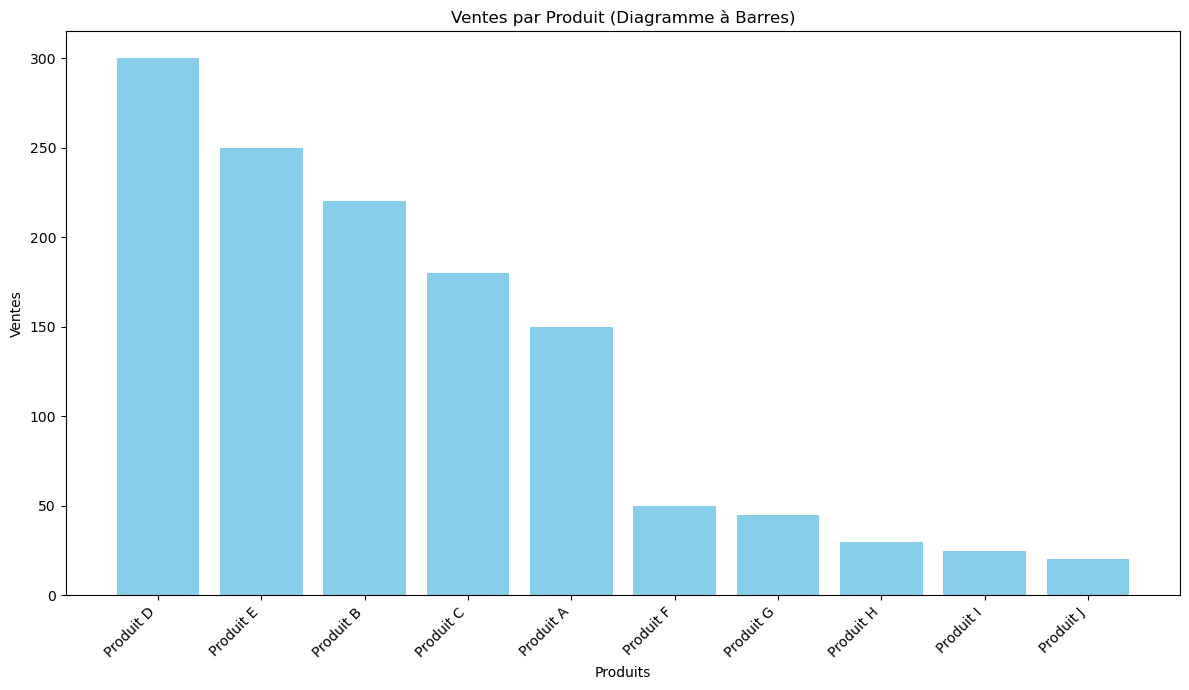

In [3]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Produit A', 'Produit B', 'Produit C', 'Produit D', 'Produit E', 
              'Produit F', 'Produit G', 'Produit H', 'Produit I', 'Produit J']
ventes = [150, 220, 180, 300, 250, 50, 45, 30, 25, 20]

sorted_indices = np.argsort(ventes)[::-1]
categories_sorted = [categories[i] for i in sorted_indices]
ventes_sorted = [ventes[i] for i in sorted_indices]

plt.figure(figsize=(12, 7))
plt.bar(categories_sorted, ventes_sorted, color='skyblue')
plt.xlabel('Produits')
plt.ylabel('Ventes')
plt.title('Ventes par Produit (Diagramme à Barres)')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Colonnes disponibles : ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


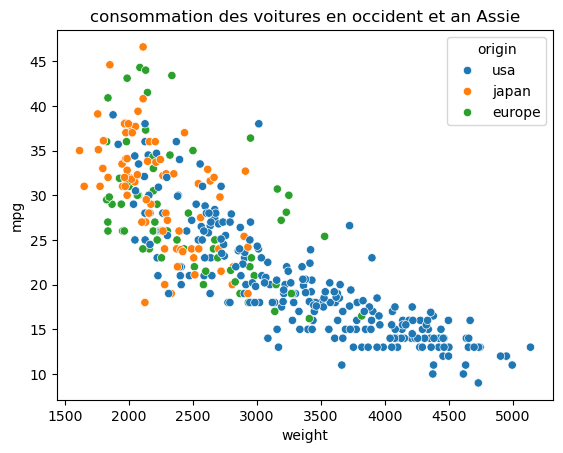

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Charger les données
mpg = sns.load_dataset('mpg')
print(mpg.head())
print("\nColonnes disponibles :", mpg.columns.tolist())

sns.scatterplot(data=mpg, x='weight', y='mpg', hue='origin', )    

plt.title('consommation des voitures en occident et an Assie')
plt.show()


on constate que un nuage de point pas très explicite

l'origin produisant les voitures les plus économes est le USA


Colonnes disponibles : 0      8
1      8
2      8
3      8
4      8
      ..
393    4
394    4
395    4
396    4
397    4
Name: cylinders, Length: 398, dtype: int64


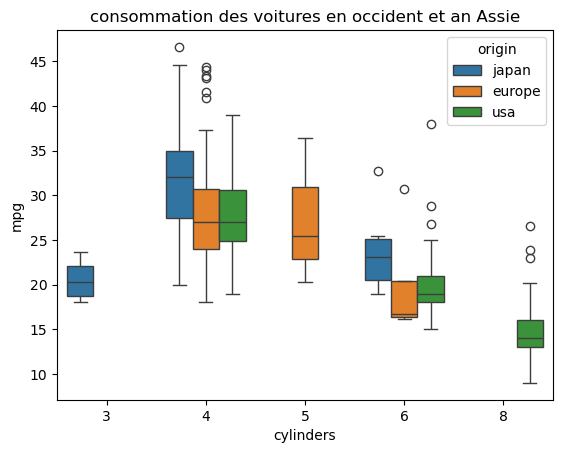

In [16]:
print("\nColonnes disponibles :", mpg['cylinders'])
sns.boxplot(data=mpg, x='cylinders', y='mpg', hue='origin', )    

plt.title('consommation des voitures en occident et an Assie')
plt.show()

l'augmentation, reel en pourcentage est 

In [6]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# --- ÉTAPE 2 : CHARGER LES DONNÉES ---
# Gapminder contient des données sur les pays (PIB, espérance de vie, population)
df = px.data.gapminder()

# On garde uniquement les pays d'Afrique
df_afrique = df[df['continent'] == 'Africa']

# On récupère la liste des pays africains
liste_pays = sorted(df_afrique['country'].unique())

# --- ÉTAPE 3 : CRÉER L'APPLICATION ---
app = dash.Dash(__name__)

# --- ÉTAPE 4 : CONSTRUIRE L'INTERFACE (LAYOUT) ---
app.layout = html.Div([
    
    # Titre principal
    html.H1("🌍 Mon premier dashboard africain", 
            style={'textAlign': 'center', 'color': '#2c3e50'}),
    
    # Menu déroulant pour choisir un pays
    html.Label("Choisissez un pays :"),
    dcc.Dropdown(
        id='selection-pays',
        options=[{'label': pays, 'value': pays} for pays in liste_pays],
        value='Senegal'  # Valeur par défaut
    ),

    # Graphique 1 : Évolution de l'espérance de vie
    dcc.Graph(id='graphique-esperance-vie'),
    
    # Graphique 2 : Carte de l'Afrique
    dcc.Graph(id='carte-afrique')
])

# --- ÉTAPE 5 : AJOUTER L'INTERACTIVITÉ (CALLBACKS) ---

# Callback pour le graphique en courbe
@app.callback(
    Output('graphique-esperance-vie', 'figure'),
    Input('selection-pays', 'value')
)

def mettre_a_jour_courbe(pays_choisi):
    # Filtrer les données pour le pays choisi
    donnees_pays = df_afrique[df_afrique['country'] == pays_choisi]
    
    # Créer le graphique
    fig = px.line(donnees_pays, 
                  x='year', 
                  y='lifeExp',
                  title=f'Espérance de vie au {pays_choisi}')
    
    return fig

# Callback pour la carte
@app.callback(
    Output('carte-afrique', 'figure'),
    Input('selection-pays', 'value')  # Même input, mais on pourrait en ajouter
)
def mettre_a_jour_carte(pays_choisi):
    # On prend l'année la plus récente
    annee_recente = df_afrique['year'].max()
    donnees_annee = df_afrique[df_afrique['year'] == annee_recente]
    
    # Créer la carte
    fig = px.choropleth(donnees_annee,
                        locations='iso_alpha',
                        color='lifeExp',
                        hover_name='country',
                        title=f'Espérance de vie en Afrique ({annee_recente})',
                        color_continuous_scale='Viridis')
    
    # Zoomer sur l'Afrique
    fig.update_geos(scope='africa')
    
    return fig

# --- ÉTAPE 6 : LANCER L'APPLICATION ---
#if __name__ == '__main__':
    app.run_server(debug=True)